In [1]:
!pip -q install wfdb ucimlrepo pandas numpy matplotlib pillow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.1 MB/s eta 0:00:00


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from ucimlrepo import fetch_ucirepo
import wfdb

print("Environment ready.")

Environment ready.


Fetching UCI Heart Disease dataset

In [4]:

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())
display(y.head())

Feature shape: (303, 13)
Target shape: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [6]:
# 0 = No heart disease
# 1-4 = Heart disease

target_col = y.columns[0]

y_binary = (
    pd.to_numeric(y[target_col], errors="coerce") > 0
).astype(int)

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(X.median(numeric_only=True))

print("Missing values:",
      int(X.isna().sum().sum()))

print("\nClass distribution:")
print(y_binary.value_counts())

Missing values: 0

Class distribution:
num
0    164
1    139
Name: count, dtype: int64


In [7]:
display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Feature Distribution

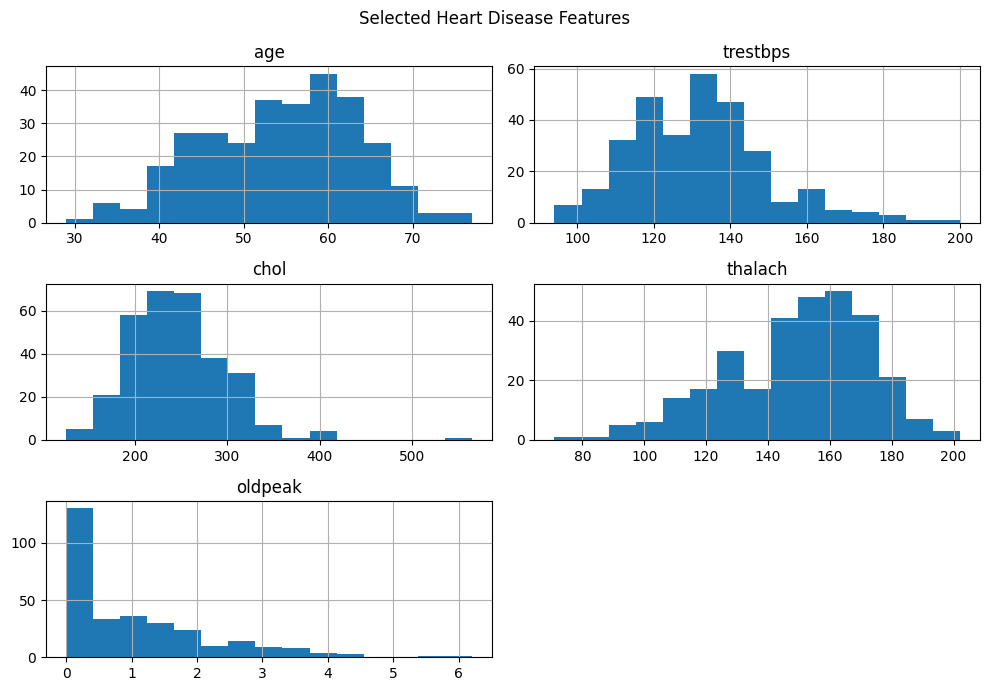

In [8]:
selected = [
    c for c in
    ["age", "trestbps", "chol", "thalach", "oldpeak"]
    if c in X.columns
]

X[selected].hist(
    figsize=(10, 7),
    bins=15
)

plt.suptitle("Selected Heart Disease Features")
plt.tight_layout()
plt.show()

Correlation Matrix

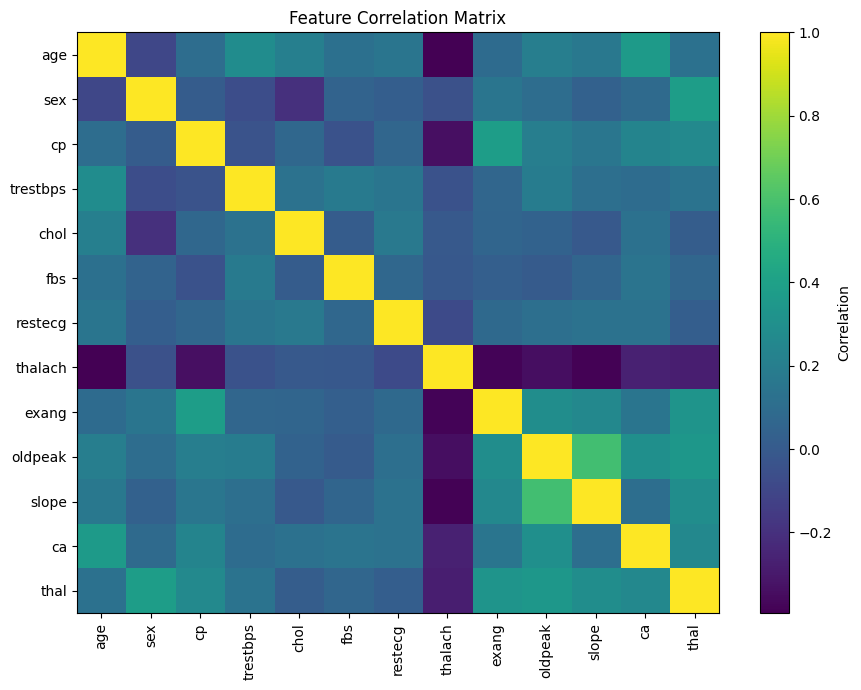

In [9]:
plt.figure(figsize=(9, 7))

plt.imshow(
    X.corr(numeric_only=True),
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=90
)

plt.yticks(
    range(len(X.columns)),
    X.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

Standardization

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(
    X_test_scaled
)[:, 1]

In [14]:
print(
    "Accuracy:",
    round(
        accuracy_score(y_test, y_pred),
        4
    )
)

print(
    "ROC AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

Accuracy: 0.8689
ROC AUC: 0.9513

Confusion Matrix:
[[27  6]
 [ 2 26]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61



ECG Record

In [15]:
# Load record 100
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print(
    "Sampling frequency:",
    record.fs,
    "Hz"
)

print(
    "Number of samples:",
    record.sig_len
)

print(
    "Number of channels:",
    record.n_sig
)

print(
    "Signal names:",
    record.sig_name
)

print(
    "Number of annotations:",
    len(annotation.sample)
)

Sampling frequency: 360 Hz
Number of samples: 650000
Number of channels: 2
Signal names: ['MLII', 'V5']
Number of annotations: 2274


ECG Signal

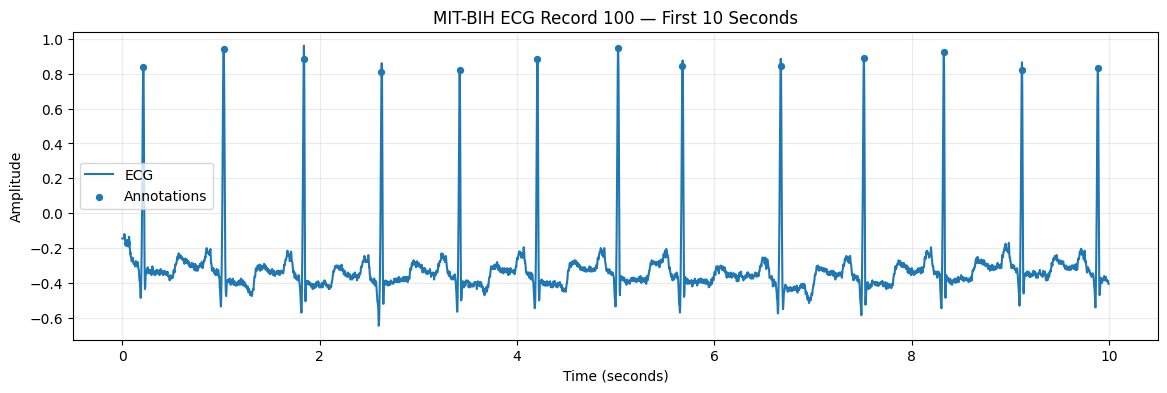

In [16]:
# Display first 10 seconds
samples = int(
    10 * record.fs
)

plt.figure(figsize=(14, 4))

plt.plot(
    np.arange(samples) / record.fs,
    record.p_signal[:samples, 0],
    label="ECG"
)

# ECG annotations
mask = annotation.sample < samples

plt.scatter(
    annotation.sample[mask] / record.fs,
    record.p_signal[
        annotation.sample[mask],
        0
    ],
    s=18,
    label="Annotations"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    "MIT-BIH ECG Record 100 — First 10 Seconds"
)

plt.legend()
plt.grid(alpha=0.25)

plt.show()

RR Interval

In [18]:
rr_samples = np.diff(
    annotation.sample
)

rr_seconds = (
    rr_samples / record.fs
)

print(
    "Number of intervals:",
    len(rr_seconds)
)

print(
    "Mean interval (seconds):",
    round(
        float(np.mean(rr_seconds)),
        4
    )
)

print(
    "Median interval (seconds):",
    round(
        float(np.median(rr_seconds)),
        4
    )
)

print(
    "Approx. mean heart rate (bpm):",
    round(
        float(60 / np.mean(rr_seconds)),
        2
    )
)

Number of intervals: 2273
Mean interval (seconds): 0.7943
Median interval (seconds): 0.7972
Approx. mean heart rate (bpm): 75.54


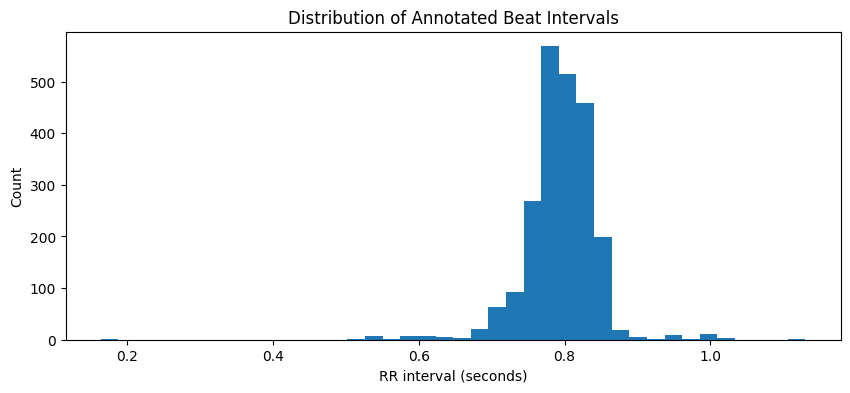

In [19]:
plt.figure(figsize=(10, 4))

plt.hist(
    rr_seconds,
    bins=40
)

plt.xlabel(
    "RR interval (seconds)"
)

plt.ylabel("Count")

plt.title(
    "Distribution of Annotated Beat Intervals"
)

plt.show()


Clinical Note

In [20]:
clinical_note = (
    "Patient reports chest discomfort after physical activity. "
    "The patient has a history of high blood pressure and "
    "elevated cholesterol. Heart rate is increased during "
    "exertion. Follow-up cardiac evaluation is recommended."
)

In [21]:
tokens = re.findall(
    r"\b[a-z]+\b",
    clinical_note.lower()
)

print(
    "Number of tokens:",
    len(tokens)
)

print("\nTokens:")
print(tokens)

Number of tokens: 31

Tokens:
['patient', 'reports', 'chest', 'discomfort', 'after', 'physical', 'activity', 'the', 'patient', 'has', 'a', 'history', 'of', 'high', 'blood', 'pressure', 'and', 'elevated', 'cholesterol', 'heart', 'rate', 'is', 'increased', 'during', 'exertion', 'follow', 'up', 'cardiac', 'evaluation', 'is', 'recommended']


In [22]:
word_freq = pd.Series(
    tokens
).value_counts()

print(
    "Most frequent words:"
)

print(
    word_freq.head(10)
)

Most frequent words:
patient       2
is            2
reports       1
discomfort    1
chest         1
physical      1
activity      1
the           1
has           1
a             1
Name: count, dtype: int64


In [23]:
keywords = [
    "chest",
    "pain",
    "discomfort",
    "blood",
    "pressure",
    "cholesterol",
    "heart",
    "rate",
    "exertion",
    "cardiac"
]

found_terms = [
    word
    for word in keywords
    if word in tokens
]

print(
    "Clinical terms found:"
)

print(found_terms)

Clinical terms found:
['chest', 'discomfort', 'blood', 'pressure', 'cholesterol', 'heart', 'rate', 'exertion', 'cardiac']


Image

In [24]:
rng = np.random.default_rng(42)

img_array = rng.normal(
    120,
    25,
    size=(256, 256)
)

img_array = np.clip(
    img_array,
    0,
    255
).astype(np.uint8)

# Add a simple circular region
yy, xx = np.ogrid[:256, :256]

mask = (
    (xx - 128)**2 +
    (yy - 128)**2
) < 35**2

img_array[mask] = np.clip(
    img_array[mask] + 70,
    0,
    255
)

img = Image.fromarray(
    img_array,
    mode="L"
)

print(
    "Image mode:",
    img.mode
)

print(
    "Image size:",
    img.size
)

print(
    "Array shape:",
    np.array(img).shape
)

Image mode: L
Image size: (256, 256)
Array shape: (256, 256)


/tmp/ipykernel_1121/153942243.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(


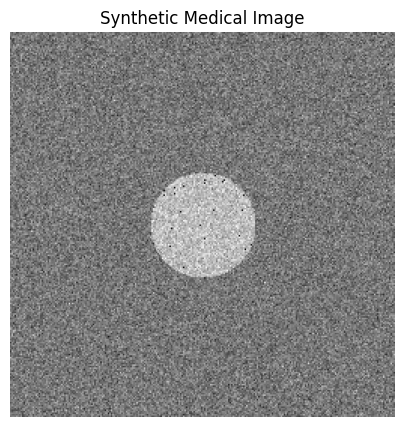

In [25]:
plt.figure(figsize=(5, 5))

plt.imshow(
    img,
    cmap="gray"
)

plt.title(
    "Synthetic Medical Image"
)

plt.axis("off")

plt.show()

In [26]:
resized_img = img.resize(
    (128, 128)
)

print(
    "Original size:",
    img.size
)

print(
    "Resized size:",
    resized_img.size
)

Original size: (256, 256)
Resized size: (128, 128)


In [27]:
summary = {

    "tabular": {
        "shape": X.shape,
        "missing_values":
            int(X.isna().sum().sum())
    },

    "text": {
        "characters":
            len(clinical_note),
        "tokens":
            len(tokens),
        "clinical_terms":
            found_terms
    },

    "image": {
        "original_size":
            img.size,
        "resized_size":
            resized_img.size,
        "mode":
            img.mode
    },

    "signal": {
        "sampling_frequency_hz":
            record.fs,
        "samples":
            record.sig_len,
        "channels":
            record.n_sig,
        "annotations":
            len(annotation.sample)
    }
}

for modality, info in summary.items():

    print(
        "\n" + modality.upper()
    )

    for key, value in info.items():

        print(
            f"{key}: {value}"
        )


TABULAR
shape: (303, 13)
missing_values: 0

TEXT
characters: 218
tokens: 31
clinical_terms: ['chest', 'discomfort', 'blood', 'pressure', 'cholesterol', 'heart', 'rate', 'exertion', 'cardiac']

IMAGE
original_size: (256, 256)
resized_size: (128, 128)
mode: L

SIGNAL
sampling_frequency_hz: 360
samples: 650000
channels: 2
annotations: 2274


Required Multimodal Pipeline

              TABULAR DATA
                   |
              TEXT DATA
                   |
              IMAGE DATA
                   |
              ECG SIGNAL
                   |
                   ↓
          +------------------+
          | Modality Loaders |
          +------------------+
                   |
                   ↓
          +------------------+
          |    Validator     |
          |   / Inspector    |
          +------------------+
                   |
                   ↓
          +------------------+
          |   Preprocessor   |
          +------------------+
                   |
                   ↓
          +------------------+
          | Optional Fusion  |
          +------------------+
                   |
                   ↓
          +------------------+
          |    AI / ML Model |
          +------------------+
                   |
                   ↓
             Final Results

**Observations**

*Tabular Data*

The UCI Heart Disease dataset can be successfully loaded using Python. Missing values are identified and handled before training the machine-learning model.

*Text Data*

The clinical note is converted into lowercase tokens. Word frequencies and relevant healthcare terms can then be extracted.

*Image Data*

The image is successfully loaded using Pillow. Its dimensions and pixel array can be inspected, and the image can be resized.

*Signal Data*

The MIT-BIH ECG record can be loaded using WFDB. The ECG waveform can be plotted, annotations can be displayed, and RR intervals can be calculated.

*Medical Data*

Combining these modalities can provide a more complete representation of a patient. The assignment notes that patient linkage, time alignment, privacy, and missing data are important challenges.